# House Price Prediction — Real Data Pipeline

Trains a Random Forest (and Gradient Boosting comparison) to predict home sale prices
in Contra Costa County, CA using **9,049 real home sales** collected via
`scripts/collect_data.py`.

**Features**: property attributes (beds, baths, sqft, lot, age, stories, garage, HOA),
spatial features (BART distance, census tract median income), city-level school score,
and macro indicators (30-yr mortgage rate, CA unemployment).

For the earlier synthetic-data approach (Phase 1, 15 real rows), see
`sdv_synthetic_model.ipynb`.

In [1]:
import math
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

sys.path.insert(0, '..')
from src.ElijahA.preprocessing import TypeDummyCreator

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv('../data/house_sales_extended.csv')
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset: 9,049 rows x 18 columns


,address,city,date_of_sale,sold_price,type,bedrooms,bathrooms,sq_ft,lot_sqft,build_age,stories,garage,hoa_fee,school_score,median_income,dist_bart_miles,unemployment,interest_rate
0,1759 Elm Rd,Concord,7/17/26,840000,Single-family,3,2.0,1504,12197.0,51,1.0,2,0.0,9,89796.0,0.795594,NaN,6.78
1,1850 Gilardy Dr,Concord,7/17/26,944888,Single-family,4,2.0,1600,7600.0,75,1.0,2,0.0,9,73873.0,1.700866,NaN,6.78
2,810 Oak Grove Rd Apt 104,Concord,7/16/26,289000,Condo,1,1.0,805,0.0,55,1.0,1,595.0,9,104194.0,1.877908,NaN,6.78
3,5515 Pennsylvania Blvd,Concord,7/16/26,770000,Single-family,4,2.0,1321,7500.0,67,1.0,2,0.0,9,100417.0,3.470854,NaN,6.78
4,1170 Mardon Ct,Concord,7/16/26,1173000,Single-family,4,2.0,2249,11700.0,47,1.0,3,0.0,9,190882.0,3.905833,NaN,6.78


In [3]:
print('--- Missing values ---')
print(df.isnull().sum().to_string())
print()
print('--- City / type breakdown ---')
print(df.groupby(['city', 'type']).size().unstack(fill_value=0).to_string())

--- Missing values ---
address             21
city                 0
date_of_sale         0
sold_price           0
type                 0
bedrooms             0
bathrooms            0
sq_ft                0
lot_sqft             0
build_age            0
stories              0
garage               0
hoa_fee              0
school_score         0
median_income      391
dist_bart_miles     13
unemployment       747
interest_rate        0

--- City / type breakdown ---
type           Condo  Single-family  Townhome
city                                         
Concord          544           2340       267
Martinez          98           1102       173
Pleasant Hill    106            722       119
Walnut Creek    1890           1297       391


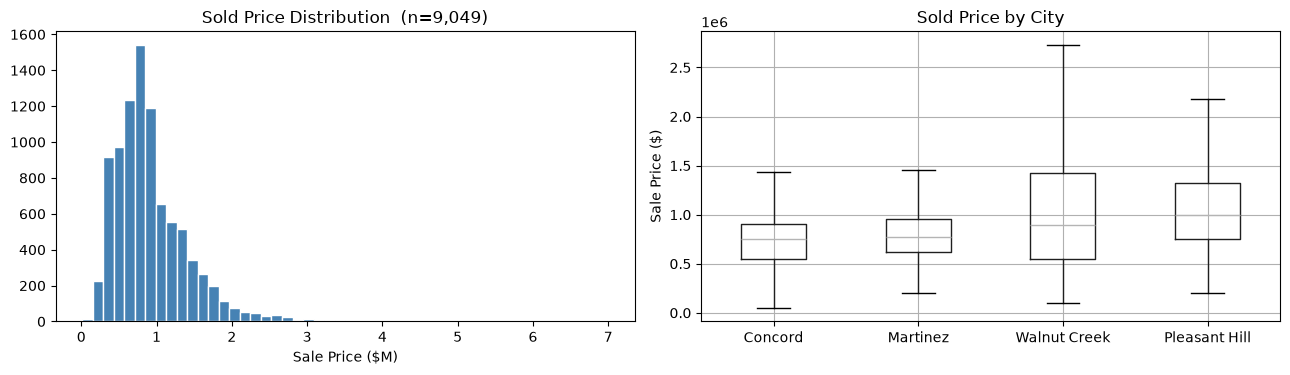

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['sold_price'] / 1e6, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Sale Price ($M)')
axes[0].set_title(f'Sold Price Distribution  (n={len(df):,})')

city_order = df.groupby('city')['sold_price'].median().sort_values().index.tolist()
df_plot = df.copy()
df_plot['city'] = pd.Categorical(df_plot['city'], categories=city_order, ordered=True)
df_plot.sort_values('city').boxplot(column='sold_price', by='city', ax=axes[1], showfliers=False)
axes[1].set_ylabel('Sale Price ($)')
axes[1].set_title('Sold Price by City')
axes[1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 2. Preprocess

**Imputation**
- `unemployment`: 739 sales lack a value (FRED ~2-month publication lag) → median impute.
- `median_income`: 391 sales unmatched by Census geocoder → median impute.
- `dist_bart_miles`: 13 sales missing lat/lon → median impute.
- `bathrooms`: scraper gaps → median impute.

**Outlier caps** (MLS data-entry errors identified in the raw data):
- `lot_sqft` → 43,560 sq ft (1 acre, 99th pct for residential)
- `garage` → 8, `stories` → 5, `bathrooms` → 6

**school_score**: city-level proxy from original 15-row dataset (GreatSchools API would give property-level values).

In [5]:
FEATURES = [
    # Property
    'type', 'city', 'bedrooms', 'bathrooms', 'sq_ft', 'lot_sqft',
    'build_age', 'stories', 'garage', 'hoa_fee',
    # Neighborhood / spatial
    'school_score', 'median_income', 'dist_bart_miles',
    # Macro
    'unemployment', 'interest_rate',
]
LABEL = 'sold_price'

OUTLIER_CAPS = {'lot_sqft': 43_560, 'garage': 8, 'stories': 5, 'bathrooms': 6}
IMPUTE_COLS  = ['unemployment', 'bathrooms', 'dist_bart_miles', 'median_income']

for col, cap in OUTLIER_CAPS.items():
    df[col] = df[col].clip(upper=cap)
for col in IMPUTE_COLS:
    df[col] = df[col].fillna(df[col].median())

print(f'Features: {len(FEATURES)}  |  Remaining NaN in features: {df[FEATURES].isnull().sum().sum()}')

Features: 15  |  Remaining NaN in features: 0


In [6]:
X = df[FEATURES].copy()
y = df[LABEL].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows')

Train: 7,239 rows  |  Test: 1,810 rows


## 3. Train — Random Forest

`TypeDummyCreator` (from `src/ElijahA/preprocessing.py`) one-hot encodes `type` and `city`
at fit time and enforces consistent output columns at inference time.

In [7]:
rf_pipeline = Pipeline([
    ('encode', TypeDummyCreator(columns=['type', 'city'])),
    ('model',  RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train)
print('Trained.')

Trained.


## 4. Evaluate on Test Set

In [8]:
rf_preds = rf_pipeline.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, rf_preds))
mae  = mean_absolute_error(y_test, rf_preds)
r2   = r2_score(y_test, rf_preds)

print(f'RMSE : ${rmse:,.0f}')
print(f'MAE  : ${mae:,.0f}')
print(f'R\u00b2   :  {r2:.3f}')

RMSE : $206,956
MAE  : $107,188
R²   :  0.829


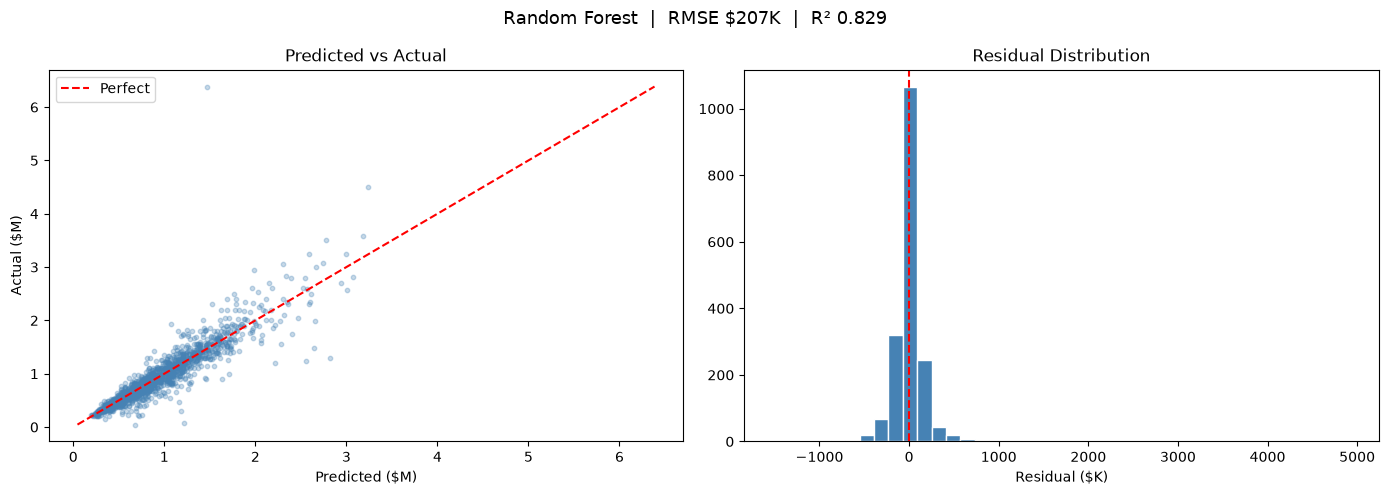

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rf_preds / 1e6, y_test / 1e6, alpha=0.3, color='steelblue', s=10)
lim = [min(y_test.min(), rf_preds.min()) / 1e6,
       max(y_test.max(), rf_preds.max()) / 1e6]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Predicted ($M)')
axes[0].set_ylabel('Actual ($M)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

residuals = y_test.values - rf_preds
axes[1].hist(residuals / 1e3, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual ($K)')
axes[1].set_title('Residual Distribution')

plt.suptitle(f'Random Forest  |  RMSE ${rmse/1e3:.0f}K  |  R\u00b2 {r2:.3f}', fontsize=13)
plt.tight_layout()
plt.show()

## 5. 5-Fold Cross-Validation

In [10]:
cv = cross_val_score(
    rf_pipeline, X, y,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
)
cv_scores = -cv
print(f'Fold RMSEs: {[f"${s:,.0f}" for s in cv_scores]}')
print(f'Mean CV RMSE: ${cv_scores.mean():,.0f} (+/- ${cv_scores.std():,.0f})')

Fold RMSEs: ['$205,576', '$174,538', '$220,818', '$173,963', '$215,879']
Mean CV RMSE: $198,155 (+/- $20,129)


## 6. Feature Importance

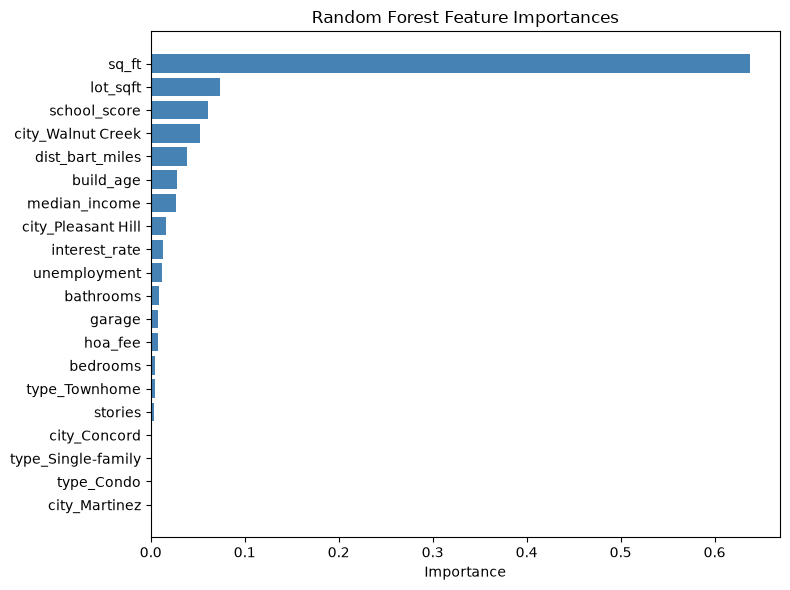

In [11]:
rf_model   = rf_pipeline.named_steps['model']
encoder    = rf_pipeline.named_steps['encode']
X_enc      = encoder.transform(X_train)
feat_names = X_enc.columns.tolist()

imp_df = pd.DataFrame({'feature': feat_names,
                        'importance': rf_model.feature_importances_
                       }).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 7. Gradient Boosting Comparison

In [12]:
gb_pipeline = Pipeline([
    ('encode', TypeDummyCreator(columns=['type', 'city'])),
    ('model',  GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)),
])
gb_pipeline.fit(X_train, y_train)

gb_preds = gb_pipeline.predict(X_test)
gb_rmse  = math.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2    = r2_score(y_test, gb_preds)
gb_cv    = -cross_val_score(gb_pipeline, X, y,
                             cv=KFold(5, shuffle=True, random_state=42),
                             scoring='neg_root_mean_squared_error')

summary = pd.DataFrame({
    'Model':       ['Random Forest', 'Gradient Boosting'],
    'Test RMSE':   [f'${rmse:,.0f}',    f'${gb_rmse:,.0f}'],
    'Test R\u00b2': [f'{r2:.3f}',        f'{gb_r2:.3f}'],
    'CV RMSE':     [f'${cv_scores.mean():,.0f} \u00b1 ${cv_scores.std():,.0f}',
                    f'${gb_cv.mean():,.0f} \u00b1 ${gb_cv.std():,.0f}'],
})
summary

,Model,Test RMSE,Test R²,CV RMSE
0,Random Forest,"$206,956",0.829,"$198,155 ± $20,129"
1,Gradient Boosting,"$211,199",0.822,"$192,290 ± $18,056"
